Осуществим склейку данных за 5 недель + метаданные ролика + метаданные пользователя

Также проведем расчет нашего таргета:
(потраченное пользователем время на просмотр / время ролика)

Таргет мы также склеим

In [5]:
!pip install pandas

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   ------ --------------------------------- 1.6/9.9 MB 6.0 MB/s eta 0:00:02
   ---------- ----------------------------- 2.6/9.9 MB 5.6 MB/s eta 0:00:02
   ------------- -------------------------- 3.4/9.9 MB 5.2 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.9 MB 5.2 MB/s eta 0:00:02
   ---------------------- ----------------- 5.5/9.9 MB 5.1 MB/s eta 0:00:01
   -------------------------- ------------- 6.6/9.9 MB 5.2 MB/s eta 0:00:01
   ------------------------------- -------- 7.9/9.9 MB 5.1 MB/s eta 0:00:01
   ------------------------------------ --- 8.9/9.9 MB 5.2 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.9 MB 5.1 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 5.0 MB/s  0:00:02
   ---------------------------------------- 0.0/12.5 MB ? eta -:--:--
   - ------------------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import os
import sys
import pandas as pd
import src.data_loader
import importlib
from src.data_loader import load_and_prepare_data, calculate_target, save_processed_data

In [7]:
try:
    import fastparquet
except ImportError:
    !pip install fastparquet
    import fastparquet

  Using cached cramjam-2.11.0-cp314-cp314-win_amd64.whl.metadata (681 bytes)
   ---------------------------------------- 0.0/701.7 kB ? eta -:--:--
   -------------- ------------------------- 262.1/701.7 kB ? eta -:--:--
   ---------------------------------------- 701.7/701.7 kB 4.4 MB/s  0:00:00
Using cached cramjam-2.11.0-cp314-cp314-win_amd64.whl (1.7 MB)

   ---------------------------------------- 0/3 [fsspec]
   ---------------------------------------- 3/3 [fastparquet]




[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
sys.path.append(os.path.abspath('..'))

importlib.reload(src.data_loader)

RAW_PATH = '../data/raw/'
PROCESSED_PATH = '../data/processed/'

df = load_and_prepare_data(RAW_PATH)

if df is not None:
    df = calculate_target(df)
    save_processed_data(df, PROCESSED_PATH, 'train_merged.parquet')
    print("Успех!")
    display(df.head())

Загружаю 5 файлов из ../data/raw/train\weeks...
Метаданные успешно приклеены.
Данные о пользователях (пол, возраст, гео) добавлены.
Целевая переменная 'target' рассчитана успешно через колонку 'duration'.
Файл сохранен: ../data/processed/train_merged.parquet
Успех!


,user_id,item_id,place,platform,agent,timespent,like,dislike,share,bookmark,click_on_author,open_comments,author_id,duration,train_interactions_rank_x,age,gender,geo,train_interactions_rank_y,target
0,4498832,289321432,0,0,0,52,False,False,False,False,False,False,285593,52,150703,25,1,78,3265575,1.000000
1,3935673,524285128,0,1,1,10,False,False,False,False,False,False,239962,73,15044,36,2,65,1554188,0.136986
2,3591171,600360983,0,0,0,7,False,False,False,False,False,False,586575,19,21069,44,2,79,3491224,0.368421
3,1291951,134985354,0,0,0,15,False,False,False,False,False,False,1051229,15,45007,39,2,78,1972759,1.000000
4,1069595,370435754,0,1,1,1,False,False,False,False,False,False,702084,14,71654,27,2,74,1139878,0.071429


Почистим код от дублей и пропусков

In [9]:
from src.preprocess import clean_data

df = clean_data(df)
print(df.dtypes)
duplicates = df.duplicated(subset=['user_id', 'item_id']).sum()
print(f"Дубликатов пар user-item: {duplicates}")

Очистка завершена. Удалено строк: 0 (0.00%)
user_id                       uint32
item_id                       uint32
place                          uint8
platform                       uint8
agent                          uint8
timespent                      uint8
like                            bool
dislike                         bool
share                           bool
bookmark                        bool
click_on_author                 bool
open_comments                   bool
author_id                     uint32
duration                       uint8
train_interactions_rank_x     uint32
age                            uint8
gender                         uint8
geo                            uint8
train_interactions_rank_y     uint32
target                       float64
dtype: object
Дубликатов пар user-item: 0


Посмотрим на распределение нашего Watch Ratio(таргета)

In [10]:
!pip install matplotlib
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp314-cp314-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp314-cp314-win_amd64.whl (8.3 MB)
Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl (232 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.3 MB ? eta -:--:--
   -------- ------------------------------- 0.5/2.3 MB 1.8 MB/s eta 0:00:01
   ----------------- ---------------------- 1.0/2.3 MB 2.1 MB/s eta 0:00:01
   -------------------------- ------------- 1.6/2.3 MB 2.0 MB/s eta 0:00:01
   ------------------

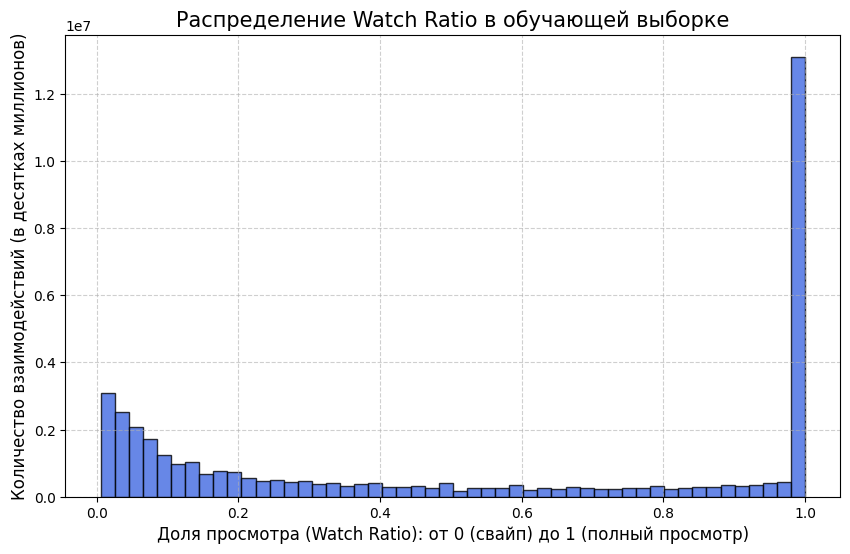

In [11]:
plt.figure(figsize=(10, 6))
df['target'].hist(bins=50, color='royalblue', edgecolor='black', alpha=0.8)

plt.title('Распределение Watch Ratio в обучающей выборке', fontsize=15)
plt.xlabel('Доля просмотра (Watch Ratio): от 0 (свайп) до 1 (полный просмотр)', fontsize=12)
plt.ylabel('Количество взаимодействий (в десятках миллионов)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

Какие можно сделать вывода по распределению:

Огромный пик справа (около 1.0): Это «Досмотры». График показывает, что в данных колоссальное количество видео, которые люди смотрят до самого конца.

Заметный подъем слева (около 0.0): Это «Свайпы». Люди часто открывают видео и закрывают его почти мгновенно (в первые 1–3 секунды).

В центре (от 0.1 до 0.9): Это «Залипание на видосик по типу чистим ковер 24часа». Это те самые видео, которые человек посмотрел наполовину или на две трети. Будем стремиться к тому чтобы модель научилась понимать, что видео, просмотренное на 0.7, намного лучше, чем видео на 0.3, даже если оба не были досмотрены до конца.

Сохраним все в новый датасет

In [12]:
save_processed_data(df, PROCESSED_PATH, 'train_clean.parquet')
print(f"Итоговое количество строк: {len(df):,}")

Файл сохранен: ../data/processed/train_clean.parquet
Итоговое количество строк: 40,618,962


In [13]:
clean_path = '../data/processed/train_clean.parquet'
if os.path.exists(clean_path):
    rows = len(df)
    cols = len(df.columns)
    print(f"Количество строк (взаимодействий): {rows:,}")
    print(f"Количество признаков (столбцов): {cols}")
    print("Список столбцов:", df.columns.tolist())
else:
    print("Файл train_clean.parquet не найден!")

Количество строк (взаимодействий): 40,618,962
Количество признаков (столбцов): 20
Список столбцов: ['user_id', 'item_id', 'place', 'platform', 'agent', 'timespent', 'like', 'dislike', 'share', 'bookmark', 'click_on_author', 'open_comments', 'author_id', 'duration', 'train_interactions_rank_x', 'age', 'gender', 'geo', 'train_interactions_rank_y', 'target']
